# Dynamic Delta Hedging Under Transaction Costs

Selling an option on futures creates an exposure that changes as the futures price moves. Delta hedging can reduce that exposure, but every rebalance has an execution cost. Hedging more aggressively can therefore reduce residual risk while making the position more expensive to manage.

The question I want to study is how a market maker should choose a hedging policy when both sides of that trade off matter. I first compare a broad set of policies under the same simulated market conditions and remove those that violate the desk's risk limits. The remaining candidates are examined through cost, downside risk, sampling uncertainty and volatility sensitivity before one policy is selected for a single realized campaign.


## 1. Research setup and 25 strategy Research Monte Carlo

The Research stage compares 25 hedging policies drawn from several rebalancing families, ranging from simple fixed rules to adaptive Whalley-Wilmott-inspired policies. Every strategy sees the same futures paths, which keeps the comparison focused on the hedge rule rather than on differences in simulated market luck.

The option value and theoretical hedge target come from Black–76. For a European call on futures with futures price $F$, strike $K$, remaining maturity $\tau$, risk-free rate $r$ and volatility $\sigma$,

$$
C(F,\tau)=e^{-r\tau}\left[F\Phi(d_1)-K\Phi(d_2)\right],
$$

where

$$
d_1=\frac{\ln(F/K)+\tfrac{1}{2}\sigma^2\tau}{\sigma\sqrt{\tau}}, \qquad
d_2=d_1-\sigma\sqrt{\tau}.
$$

The corresponding call delta with respect to the futures price is

$$
\Delta_{\mathrm{call}}=e^{-r\tau}\Phi(d_1).
$$

Here $\Phi(\cdot)$ is the standard normal cumulative distribution function. All 25 policies use the same Black–76 price and the same theoretical delta target. What changes is the rule that decides when, and by how much, the actual futures hedge should move once transaction costs matter.

Black–76 pricing and Greeks use the Research volatility throughout this stage. The futures bid–ask spread is treated as a known execution input, so each policy is evaluated with the same pricing assumptions and transaction cost environment.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from dynamic_delta_hedging.campaign import (
    build_trade_trace,
    research_downside_loss_reference_for_strategy,
    run_realized_campaign,
    validate_final_strategy_choice,
)
from dynamic_delta_hedging.config import HedgingConfig
from dynamic_delta_hedging.experiments import (
    create_strategy_universe_metrics_table,
    run_all_experiments,
)
from dynamic_delta_hedging.plotting import (
    plot_realized_campaign_drawdown,
    plot_realized_campaign_equity,
    plot_realized_campaign_trade_pnls,
    plot_trade_cost_and_hedge_pnl,
    plot_trade_futures_path,
    plot_trade_hedge,
)
from dynamic_delta_hedging.presentation import (
    display_cost_es_frontier,
    display_desk_mandate,
    display_feasible_strategies,
    display_frontier_stability,
    display_locked_campaign_setup,
    display_pairwise_comparisons,
    display_realized_campaign,
    display_selected_quote,
    display_trade_inception,
    display_trade_postmortem,
    display_volatility_robustness_summary,
)
from dynamic_delta_hedging.pricing import black76_call_delta, black76_call_price
from dynamic_delta_hedging.quoting import create_strategy_quote_recommendations
from dynamic_delta_hedging.research_analysis import (
    add_cost_es_frontier_flag,
    bootstrap_cost_es_frontier_stability,
    cost_es_frontier_strategy_ids,
    create_focused_pairwise_comparisons,
)
from dynamic_delta_hedging.robustness import (
    create_robustness_metrics_table,
    run_robustness_analysis,
)
from dynamic_delta_hedging.selection import (
    apply_desk_mandate,
    create_desk_mandate_from_percentages,
    require_mandate_eligible_strategy_ids,
)

In [2]:
# User-configurable Research inputs
F0 = 100.0                         # Initial futures price
K = 100.0                          # Option strike price
T = 0.5                            # Time to maturity in years
R = 0.03                           # Annual risk-free interest rate
SIGMA_RESEARCH = 0.25              # Implied/model volatility used by Black-76 pricing and Greeks
MU = 0.0                           # Annual drift used to simulate futures paths
FUTURES_SPREAD_RESEARCH = 0.001    # Full proportional futures bid-ask spread; 0.001 = 0.10%
CURRENCY = "EUR"                   # Currency used for contract-level reporting
CONTRACT_MULTIPLIER = 100.0        # Currency value applied to one option price unit per contract
N_STEPS = 126                      # Simulation time steps over the option's life
N_PATHS = 10_000                   # Common Monte Carlo paths used to compare all strategies
RESEARCH_SEED = None               # Integer for reproducible Research paths; None draws a fresh sample

# User-configurable Research analysis inputs
TARGET_EXPECTED_TERMINAL_PROFIT_EUR = 0.00  # Target expected terminal profit per contract used to set the recommended ask
N_BOOTSTRAP = 2_000                        # Number of bootstrap resamples used for frontier stability
BOOTSTRAP_SEED = None                      # Integer for reproducible bootstrap resampling; None draws a fresh sample
ROBUSTNESS_SEED = None                     # Integer for reproducible robustness paths; None draws a fresh sample
ROBUSTNESS_N_PATHS = 10_000                # Monte Carlo paths used in each volatility robustness scenario
TAIL_PROBABILITY = 0.05                     # Lower-tail probability used for Expected Shortfall and Tail Loss; 0.05 = 5%
PAIRED_CONFIDENCE_LEVEL = 0.95              # Confidence level used for paired-comparison uncertainty intervals

research_config = HedgingConfig(
    F0=F0,
    K=K,
    T=T,
    r=R,
    sigma=SIGMA_RESEARCH,
    futures_spread=FUTURES_SPREAD_RESEARCH,
    option_spread=0.0,
    currency=CURRENCY,
    contract_multiplier=CONTRACT_MULTIPLIER,
    n_steps=N_STEPS,
    n_paths=N_PATHS,
    mu=MU,
    seed=RESEARCH_SEED,
)

theoretical_option_price = black76_call_price(F0, T, research_config)
initial_black76_delta = black76_call_delta(F0, T, research_config)
fair_contract_value = theoretical_option_price * CONTRACT_MULTIPLIER

display_trade_inception(
    theoretical_option_price,
    fair_contract_value,
    initial_black76_delta,
)

research_experiment = run_all_experiments(research_config)
research_metrics = create_strategy_universe_metrics_table(
    research_experiment,
    tail_probability=TAIL_PROBABILITY,
)

Black-76 Theoretical Price (price units),Contract Fair Value (€),Initial Black-76 Delta
6.938338,693.83,0.527248


## 2. Desk Mandate filtering

Before comparing the surviving strategies in detail, I remove any policy that falls outside the desk's accepted risk or cost limits. A strategy must satisfy

$$
\sigma_P \le L_\sigma, \qquad ES_{5\%} \ge L_{ES}, \qquad \mathbb{E}[C] \le L_C.
$$

The mandate is an eligibility rule rather than a ranking system. A policy that breaches one of these limits is excluded even if it looks attractive on another metric. The limits are expressed relative to the option's fair contract value so that the same framework can scale with the size of the option exposure.


In [3]:
# User-configurable Desk Mandate limits, expressed as percentages of Black-76 fair contract value
MAX_PNL_STD_PCT = 13               # Maximum terminal P&L standard deviation
MAX_TAIL_LOSS_5_PCT = 30           # Maximum positive 5% Tail Loss
MAX_MEAN_HEDGING_COST_PCT = 5      # Maximum mean futures hedging transaction cost

DESK_MANDATE = create_desk_mandate_from_percentages(
    fair_contract_value,
    max_pnl_std_pct=MAX_PNL_STD_PCT,
    max_tail_loss_5_pct=MAX_TAIL_LOSS_5_PCT,
    max_mean_hedging_cost_pct=MAX_MEAN_HEDGING_COST_PCT,
)

display_desk_mandate(
    DESK_MANDATE.max_pnl_std,
    DESK_MANDATE.min_es_5,
    DESK_MANDATE.max_mean_cost,
)

research_selection = apply_desk_mandate(research_metrics, DESK_MANDATE)
mandate_eligible_strategy_ids = require_mandate_eligible_strategy_ids(
    research_selection
)
eligible_metrics = research_selection.feasible_metrics.copy()

Max P&L Std (€),Min ES 5% (€),Max Mean Hedging Cost (€)
90.20,-208.15,34.69


## 3. Research Quote Recommendations and Candidate Summary

Black–76 gives the model value of the option, but it does not tell the desk how expensive the resulting position will be to manage. Different hedge policies generate different expected hedging economics, so they can support different break even selling prices.

Quote recommendations are calculated only for strategies that have already passed the Desk Mandate. They use Research information available before deployment. Later campaign outcomes never feed back into the price at which the trade would originally have been accepted.

### How the five hedging families rebalance

The same Black–76 delta $\Delta_t$ is the theoretical hedge target for every family. I use $q_t$ for the current futures hedge position, $F_t$ for the current futures price, $\tau$ for remaining maturity and $\Gamma_t$ for Black–76 gamma. Every policy starts from the exact delta hedge at inception. The difference is the rule used after that point.

**Fixed interval** resets the hedge fully to $\Delta_t$ every $m$ simulation steps and leaves it unchanged between scheduled rebalances.

$$
q_t^{\mathrm{new}}=
\begin{cases}
\Delta_t, & n \bmod m = 0,\\
q_t, & \text{otherwise}.
\end{cases}
$$

Changing $m$ creates a different strategy within the family. The five values used here are $1$, $2$, $5$, $10$ and $21$ steps, so a smaller $m$ means more frequent rebalancing.

**Fixed band** places a constant no-trade region around the current delta. With half-width $b$,

$$
L_t=\max(0,\Delta_t-b), \qquad U_t=\min(1,\Delta_t+b).
$$

If $q_t$ falls below $L_t$ or above $U_t$, the hedge moves only to the nearest boundary. Otherwise it is left unchanged. The five values of $b$ are $0.01$, $0.02$, $0.03$, $0.05$ and $0.10$. A wider band accepts more delta deviation in exchange for less trading.

**Whalley-Wilmott-inspired** uses the same nearest-boundary idea, but the half-width changes with the local option risk and market state rather than remaining fixed. The adapted half-width is

$$
h_t=
\left(
\frac{3cF_t e^{-r\tau}}{2\lambda}
\right)^{1/3}
|\Gamma_t|^{2/3},
$$

where $c$ is one half of the full proportional futures bid–ask spread and $\lambda$ controls risk aversion. The five values of $\lambda$ are $0.25$, $0.50$, $1.00$, $2.00$ and $4.00$. Higher $\lambda$ produces a narrower no-trade region and therefore more aggressive rebalancing. The rule keeps the Whalley-Wilmott functional form but adapts it to options on futures through Black–76 delta and gamma, so it is treated as Whalley-Wilmott-inspired rather than as an exact futures-specific optimum.

**Delta tolerance** waits until the actual hedge has drifted far enough from the current delta, then rebalances fully back to the target.

$$
q_t^{\mathrm{new}}=
\begin{cases}
\Delta_t, & |\Delta_t-q_t|>\varepsilon,\\
q_t, & \text{otherwise}.
\end{cases}
$$

The tolerance $\varepsilon$ takes the values $0.01$, $0.02$, $0.03$, $0.05$ and $0.10$. Unlike the fixed-band family, crossing the threshold triggers a full move back to delta rather than a move only to the edge of a band.

**Asset tolerance** uses movement in the futures price as the trigger. If $F_t^{\mathrm{last}}$ is the futures price at the most recent hedge trade,

$$
q_t^{\mathrm{new}}=
\begin{cases}
\Delta_t, & \left|\dfrac{F_t-F_t^{\mathrm{last}}}{F_t^{\mathrm{last}}}\right|>a,\\
q_t, & \text{otherwise}.
\end{cases}
$$

The price-move tolerance $a$ takes the values $1.50\%$, $2.25\%$, $3.50\%$, $5.00\%$ and $7.00\%$. A larger value allows the futures price to travel further from the last hedge point before another full delta rebalance is triggered.

In [4]:
quote_recommendations = create_strategy_quote_recommendations(
    eligible_metrics,
    research_config,
    target_expected_terminal_profit_eur=TARGET_EXPECTED_TERMINAL_PROFIT_EUR,
)

eligible_with_quotes = eligible_metrics.merge(
    quote_recommendations[[
        "strategy_id",
        "break_even_ask_eur",
        "recommended_ask_eur",
    ]],
    on="strategy_id",
    how="left",
    validate="one_to_one",
)

display_feasible_strategies(
    eligible_with_quotes,
    research_selection.status,
    mandate_eligible_strategy_ids,
)

Research status: multiple; feasible strategies: ('A', 'B', 'F', 'G', 'H', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'U', 'V')


,Strategy ID,Strategy Name,Mean P&L (€),P&L Std (€),ES 5% (€),Mean Hedging Cost (€),Mean Trades,Mean Turnover,Break-even Ask (€),Recommended Ask (€)
1,A,Fixed Interval 1,-24.24,55.35,-158.45,22.91,125,4.52,717.72,717.72
2,B,Fixed Interval 2,-18.06,76.65,-198.96,17.68,63,3.47,711.62,711.62
3,F,Fixed Band 0.01,-19.86,57.39,-155.07,18.60,96,3.66,713.40,713.40
4,G,Fixed Band 0.02,-16.94,63.02,-159.61,15.93,80,3.12,710.52,710.52
5,H,Fixed Band 0.03,-15.02,70.92,-171.17,14.14,68,2.77,708.63,708.63
6,L,WW-inspired λ=0.50,-12.84,81.76,-191.53,12.13,56,2.36,706.48,706.48
7,M,WW-inspired λ=1.00,-13.94,74.02,-178.23,13.11,63,2.55,707.57,707.57
8,N,WW-inspired λ=2.00,-15.03,68.25,-168.52,14.13,70,2.76,708.64,708.64
9,O,WW-inspired λ=4.00,-16.15,64.12,-162.74,15.18,77,2.97,709.74,709.74
10,P,Delta Tolerance 0.01,-23.69,55.64,-158.16,22.28,86,4.39,717.17,717.17


## 4. Primary Cost and ES Efficient Hedging Frontier

Expected hedging cost and downside risk are the two main economic objectives used to compare the remaining policies. Downside risk is written as positive 5% Tail Loss

$$
\mathrm{Tail\ Loss}_{5\%} = -ES_{5\%}(\mathrm{P\&L}).
$$

Both quantities are minimized. A strategy is dominated when another qualified policy achieves both lower expected cost and lower tail loss. A policy that remains on the frontier is not automatically the best choice. It simply represents a cost and risk trade off that cannot be improved in one direction without giving something up in the other.


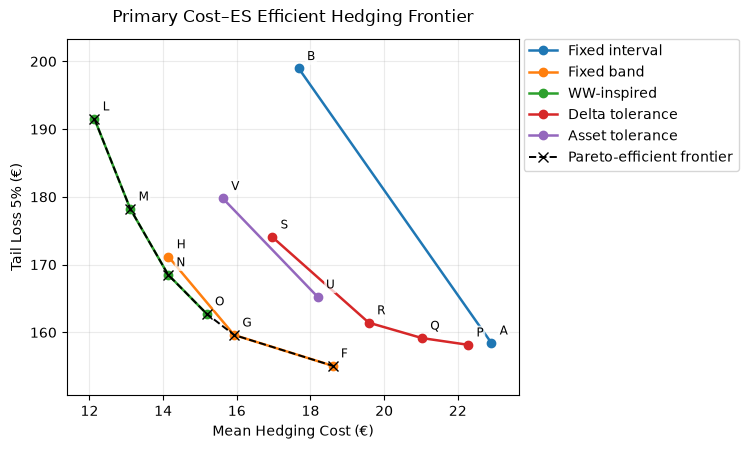

Strategy ID,Strategy Name,Mean Hedging Cost (€),Tail Loss 5% (€),Primary Frontier
A,Fixed Interval 1,22.91,158.45,Dominated
B,Fixed Interval 2,17.68,198.96,Dominated
F,Fixed Band 0.01,18.60,155.07,Efficient
G,Fixed Band 0.02,15.93,159.61,Efficient
H,Fixed Band 0.03,14.14,171.17,Dominated
L,WW-inspired λ=0.50,12.13,191.53,Efficient
M,WW-inspired λ=1.00,13.11,178.23,Efficient
N,WW-inspired λ=2.00,14.13,168.52,Efficient
O,WW-inspired λ=4.00,15.18,162.74,Efficient
P,Delta Tolerance 0.01,22.28,158.16,Dominated


In [5]:
primary_frontier = add_cost_es_frontier_flag(eligible_metrics)
serious_candidate_strategy_ids = cost_es_frontier_strategy_ids(primary_frontier)

display_cost_es_frontier(
    primary_frontier,
    research_selection.n_feasible,
)

## 5. Bootstrap Frontier Stability

A frontier can look convincing and still depend too heavily on the particular Monte Carlo sample that happened to be drawn. To check that, each bootstrap replication resamples the same Research path indices for every qualified strategy and rebuilds the Cost and ES frontier. For strategy $i$

$$
\mathrm{Stability}_i = \frac{1}{B}\sum_{b=1}^{B}\mathbf{1}\{i\text{ is efficient in bootstrap }b\}.
$$

High stability means that frontier membership survives repeated resampling of the available Research paths. It does not mean that the strategy has that probability of being truly optimal, and it is not used as a separate pass or fail rule.


In [6]:
frontier_stability = bootstrap_cost_es_frontier_stability(
    research_selection,
    research_experiment,
    tail_probability=TAIL_PROBABILITY,
    n_bootstrap=N_BOOTSTRAP,
    seed=BOOTSTRAP_SEED,
)

display_frontier_stability(frontier_stability)

Strategy ID,Strategy Name,Primary Frontier,Bootstrap Frontier Stability
A,Fixed Interval 1,Dominated,0.0%
B,Fixed Interval 2,Dominated,0.0%
F,Fixed Band 0.01,Efficient,100.0%
G,Fixed Band 0.02,Efficient,100.0%
H,Fixed Band 0.03,Dominated,15.8%
L,WW-inspired λ=0.50,Efficient,100.0%
M,WW-inspired λ=1.00,Efficient,100.0%
N,WW-inspired λ=2.00,Efficient,99.8%
O,WW-inspired λ=4.00,Efficient,100.0%
P,Delta Tolerance 0.01,Dominated,0.0%


## 6. Focused Paired Comparisons

The frontier compares strategies through aggregate cost and tail risk. Paired analysis asks a different question. It looks at whether two serious candidates tend to produce different P&L on the same underlying market paths.

Because both strategies face the same Research paths, I compare the pathwise difference

$$
D_i = P_i^{(A)} - P_i^{(B)}.
$$

Much of the shared Monte Carlo noise cancels in the comparison. If the uncertainty interval around the paired difference includes zero, I treat the result as inconclusive rather than manufacturing a winner from a difference that the simulation cannot distinguish reliably.


In [7]:
paired_research_comparisons = create_focused_pairwise_comparisons(
    research_selection,
    research_experiment,
    serious_candidate_strategy_ids,
    confidence_level=PAIRED_CONFIDENCE_LEVEL,
)

display_pairwise_comparisons(
    paired_research_comparisons,
    research_selection.evaluated_metrics,
    serious_candidate_strategy_ids,
)

## 7. Volatility Robustness and Sensitivity

The final Research check asks how the surviving policies behave when realized volatility differs from the volatility used to price and hedge the option. Black–76 pricing and Greeks continue to use the fixed Research volatility while only the futures path volatility changes across

$$
0.75\sigma_{\mathrm{research}}, \qquad 1.00\sigma_{\mathrm{research}}, \qquad 1.25\sigma_{\mathrm{research}}.
$$

Keeping the hedge model fixed deliberately creates an implied versus realized volatility mismatch without giving the strategy any information from the future. The same standardized Brownian shocks are reused across strategies and scenarios, and the futures execution spread remains unchanged.


In [8]:
robustness_results = run_robustness_analysis(
    research_config,
    research_selection,
    n_paths=ROBUSTNESS_N_PATHS,
    seed=ROBUSTNESS_SEED,
    tail_probability=TAIL_PROBABILITY,
    verbose=False,
)
robustness_table = create_robustness_metrics_table(robustness_results)

display_volatility_robustness_summary(robustness_table)

Strategy ID,Strategy Name,Mean P&L 0.75σ (€),Mean P&L 1.00σ (€),Mean P&L 1.25σ (€),ES 5% 0.75σ (€),ES 5% 1.00σ (€),ES 5% 1.25σ (€)
A,Fixed Interval 1,154.36,-24.15,-201.89,39.44,-161.23,-474.06
B,Fixed Interval 2,158.76,-19.07,-196.33,22.16,-204.70,-526.94
F,Fixed Band 0.01,158.63,-19.87,-197.65,31.76,-157.72,-466.41
G,Fixed Band 0.02,161.07,-17.16,-194.84,16.54,-162.54,-461.87
H,Fixed Band 0.03,162.62,-15.31,-192.85,-2.68,-173.78,-461.15
L,WW-inspired λ=0.50,164.39,-13.24,-190.63,-3.41,-192.38,-489.47
M,WW-inspired λ=1.00,163.67,-14.25,-191.99,8.63,-181.41,-481.39
N,WW-inspired λ=2.00,162.87,-15.41,-193.14,17.73,-173.23,-475.29
O,WW-inspired λ=4.00,161.93,-16.43,-194.28,24.29,-167.25,-471.06
P,Delta Tolerance 0.01,155.05,-23.52,-201.22,38.71,-161.31,-474.33


## 8. Manual Final Strategy Selection and Lock

The Research evidence narrows the choice, but it is not forced into a single mechanical winner. Efficient candidates can represent different compromises between hedging cost and downside risk, so the final choice remains an explicit desk decision informed by the mandate, frontier, bootstrap, paired comparisons and volatility sensitivity.

The selected strategy must already belong to the Desk Mandate survivor set. Once chosen, its Research quote and downside loss reference are locked before deployment. Realized campaign results are not allowed to revise that earlier decision with hindsight.


In [10]:
# User-configurable final strategy and realized campaign controls
FINAL_SELECTED_STRATEGY = "M"      # Strategy ID chosen from the Desk Mandate survivor set

STARTING_CAPITAL = 25_000.0         # Capital available before the first campaign trade
RISK_BUDGET_FRACTION = 0.03         # Fraction of pre-trade capital allocated to the Research downside-loss reference for sizing
MAX_DRAWDOWN_LIMIT = 0.20           # Stop the campaign when drawdown from the running capital peak reaches this fraction
N_CAMPAIGN_TRADES = 30              # Maximum number of sequential option episodes planned
REALIZED_CAMPAIGN_SEED = None       # Integer reuses the same exogenous market environment; None creates a fresh campaign

FINAL_SELECTED_STRATEGY = validate_final_strategy_choice(
    FINAL_SELECTED_STRATEGY,
    research_selection,
)

selected_quote = quote_recommendations.loc[
    quote_recommendations["strategy_id"] == FINAL_SELECTED_STRATEGY
].iloc[0]

LOCKED_OPTION_SPREAD = float(selected_quote.recommended_option_spread)

RESEARCH_DOWNSIDE_LOSS_REFERENCE = research_downside_loss_reference_for_strategy(
    research_selection,
    FINAL_SELECTED_STRATEGY,
)

display_selected_quote(
    FINAL_SELECTED_STRATEGY,
    selected_quote,
    TARGET_EXPECTED_TERMINAL_PROFIT_EUR,
)

display_locked_campaign_setup(
    strategy_id=FINAL_SELECTED_STRATEGY,
    strategy_name=selected_quote.strategy_name,
    recommended_ask_eur=selected_quote.recommended_ask_eur,
    recommended_option_spread=LOCKED_OPTION_SPREAD,
    fixed_futures_spread=FUTURES_SPREAD_RESEARCH,
    starting_capital=STARTING_CAPITAL,
    risk_budget_fraction=RISK_BUDGET_FRACTION,
    loss_reference_per_contract=RESEARCH_DOWNSIDE_LOSS_REFERENCE,
    max_drawdown_limit=MAX_DRAWDOWN_LIMIT,
    n_campaign_trades=N_CAMPAIGN_TRADES,
    campaign_seed=REALIZED_CAMPAIGN_SEED,
)

Strategy ID,Strategy Name,Black-76 Fair Contract Value (€),Break-even Ask (€),Recommended Ask (€),Target Expected Terminal Profit (€),Implied Full Option Spread (%)
M,WW-inspired λ=1.00,693.83,707.57,707.57,0.00,3.96


Locked Item,Value
Strategy,M — WW-inspired λ=1.00
Research-derived Option Ask,€707.57
Research-derived Option Spread,3.9586%
Fixed Futures Execution Spread,0.100%
Starting Capital,"€25,000.00"
Risk Budget Fraction,3.00% of pre-trade capital
Research Downside Loss Reference per Contract,€178.23 per contract
Maximum Drawdown Limit,20.00%
Planned Campaign Trades,30
Campaign Seed,Fresh / Random


## 9. One Realized Trading Campaign

After the strategy is locked, I observe one sequential finite capital campaign rather than averaging over another Monte Carlo layer. Each campaign trade is a complete option episode. A new option is sold, dynamically hedged over its life, settled at expiry and its terminal P&L is added to capital before the next trade begins.

The campaign seed generates the exogenous market environment before strategy execution, including one realized volatility draw and one Brownian shock sequence for each planned trade. For every trade

$$
\sigma_{\mathrm{realized}} \sim \operatorname{Triangular}\!\left(
0.75\sigma_{\mathrm{research}},
\sigma_{\mathrm{research}},
1.25\sigma_{\mathrm{research}}
\right).
$$

Using the same integer seed with another qualified strategy therefore recreates the same market paths for a controlled counterfactual comparison. Position size is based on pre trade capital and the selected strategy's Research downside loss reference. The maximum drawdown limit is the only explicit campaign kill switch, while zero contract sizing simply prevents another position from being opened.


Trade,Realized σ,Contracts,Per-Contract P&L (€),Total Trade P&L (€),Capital After Trade (€),Drawdown,Status
1,21.41%,4,121.76,487.05,"25,487.05",0.00%,ACTIVE
2,24.92%,4,-104.59,-418.34,"25,068.70",1.64%,ACTIVE
3,27.42%,4,-49.31,-197.24,"24,871.46",2.42%,ACTIVE
4,23.68%,4,105.28,421.13,"25,292.59",0.76%,ACTIVE
5,24.34%,4,-50.25,-201.00,"25,091.59",1.55%,ACTIVE
6,24.32%,4,21.61,86.44,"25,178.04",1.21%,ACTIVE
7,26.28%,4,30.21,120.85,"25,298.88",0.74%,ACTIVE
8,25.04%,4,119.23,476.91,"25,775.79",0.00%,ACTIVE
9,25.86%,4,52.85,211.40,"25,987.19",0.00%,ACTIVE
10,22.19%,4,141.82,567.26,"26,554.45",0.00%,ACTIVE


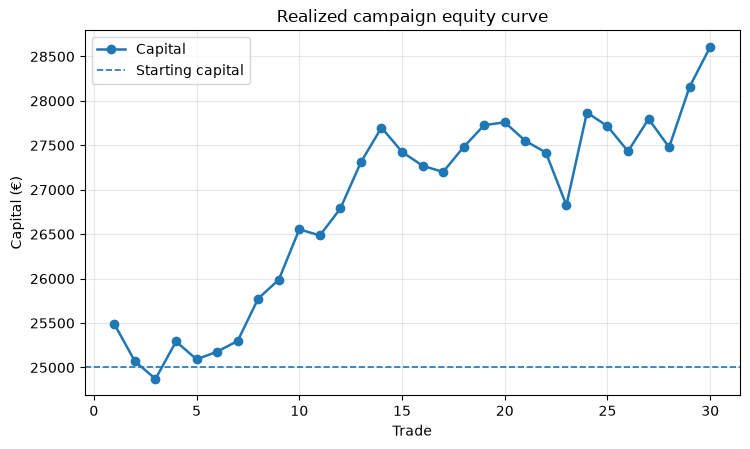

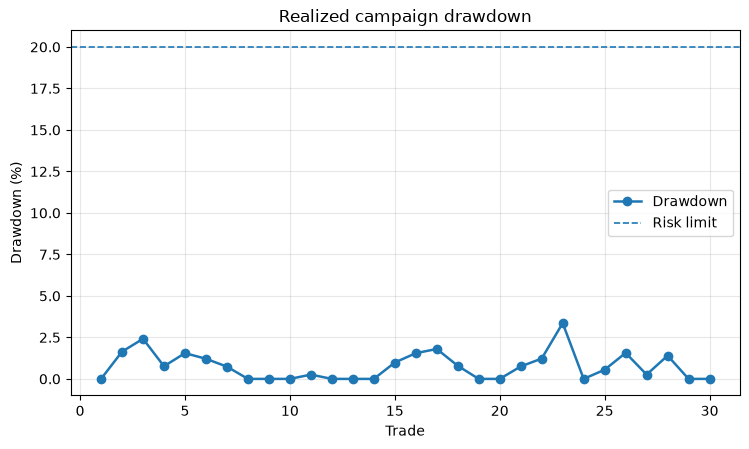

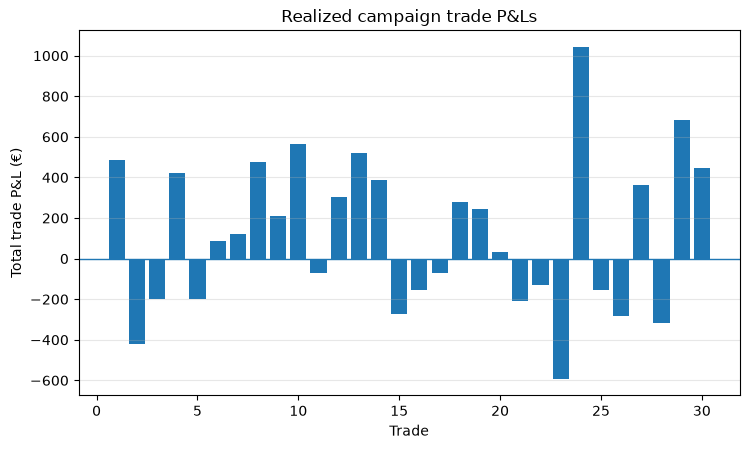

In [12]:
realized_campaign = run_realized_campaign(
    research_config,
    research_selection,
    quote_recommendations,
    FINAL_SELECTED_STRATEGY,
    starting_capital=STARTING_CAPITAL,
    risk_budget_fraction=RISK_BUDGET_FRACTION,
    max_drawdown_limit=MAX_DRAWDOWN_LIMIT,
    n_trades=N_CAMPAIGN_TRADES,
    seed=REALIZED_CAMPAIGN_SEED,
)

display_realized_campaign(realized_campaign)

FIGURES_DIR = Path("figures")  # Output directory for generated figures
FIGURES_DIR.mkdir(exist_ok=True)

plot_realized_campaign_equity(
    realized_campaign,
    save_path=FIGURES_DIR / "realized_campaign_equity.png",
)
plt.show()
plt.close("all")

plot_realized_campaign_drawdown(
    realized_campaign,
    save_path=FIGURES_DIR / "realized_campaign_drawdown.png",
)
plt.show()
plt.close("all")

plot_realized_campaign_trade_pnls(
    realized_campaign,
    save_path=FIGURES_DIR / "realized_campaign_trade_pnls.png",
)
plt.show()
plt.close("all")

## 10. Realized Campaign Trade Review

Any executed campaign trade can be selected for a detailed replay. The stored market environment reconstructs the same realized volatility and futures path exactly when an integer campaign seed is used.

The replay is meant to connect the market path with what happened inside the hedge. It shows how the Black–76 delta evolved, when the hedge moved, how transaction costs accumulated and how the option liability and hedge combined into terminal P&L. Per contract economics are kept separate from the total effect on campaign capital.


Selected Trade,Realized σ,Terminal Futures Price,Strike,Expiry Status,Contracts,Hedge Trades,Transaction Cost (€),Hedge P&L (€),Option Payoff (€),Per-Contract Terminal P&L (€),Total Trade P&L (€)
1,21.41%,113.52,100.00,ITM,4,56,13.97,765.59,"1,352.20",121.76,487.05


Component,Per-Contract Contribution (€)
Option Sale Proceeds,707.57
Cash Interest Accrual,14.77
Hedge P&L,765.59
Transaction Costs,-13.97
Option Payoff Liability,"-1,352.20"
Terminal P&L,121.76


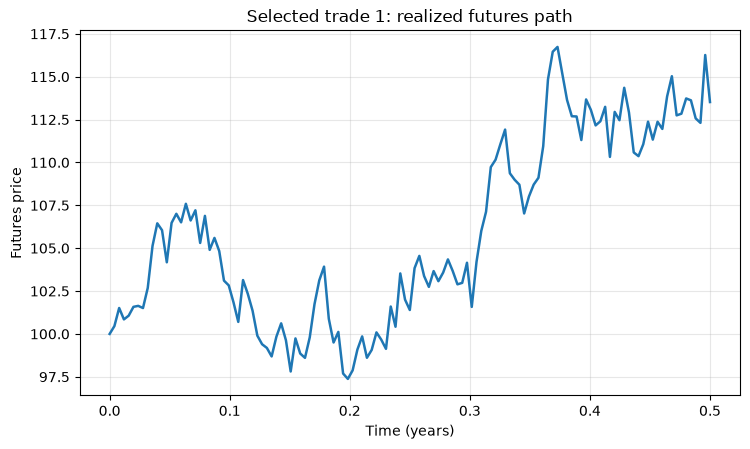

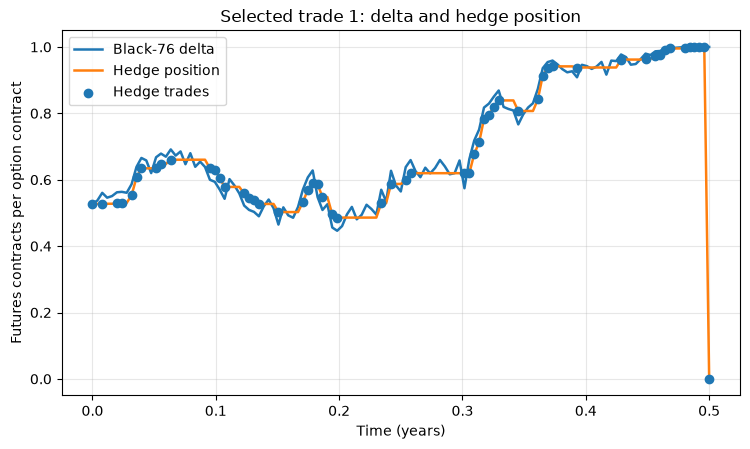

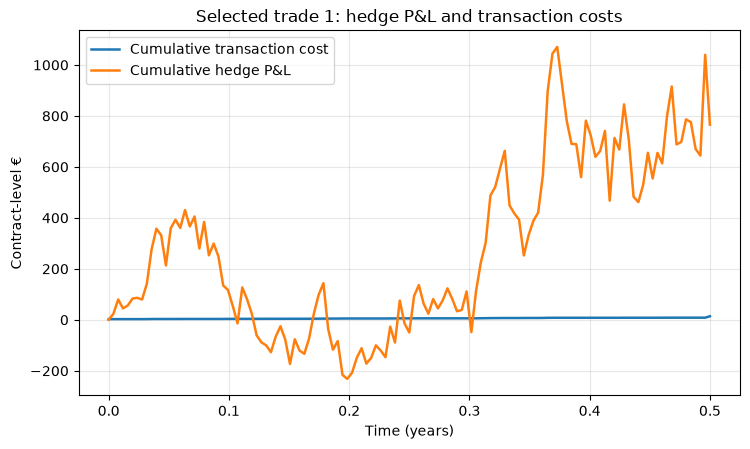

In [13]:
# User-configurable trade review input
TRADE_TO_REVIEW = 1                 # Executed campaign trade number to replay, using 1-based numbering

selected_trade_trace = build_trade_trace(
    realized_campaign,
    TRADE_TO_REVIEW,
)

display_trade_postmortem(
    realized_campaign,
    TRADE_TO_REVIEW,
    trace=selected_trade_trace,
)

plot_trade_futures_path(
    selected_trade_trace,
    trade_number=TRADE_TO_REVIEW,
    save_path=FIGURES_DIR / "selected_trade_futures_path.png",
)
plt.show()
plt.close("all")

plot_trade_hedge(
    selected_trade_trace,
    trade_number=TRADE_TO_REVIEW,
    save_path=FIGURES_DIR / "selected_trade_hedge.png",
)
plt.show()
plt.close("all")

plot_trade_cost_and_hedge_pnl(
    selected_trade_trace,
    trade_number=TRADE_TO_REVIEW,
    save_path=FIGURES_DIR / "selected_trade_cost_and_hedge_pnl.png",
)
plt.show()
plt.close("all")